📂 총 17개의 정상 로그 파일을 분석합니다.


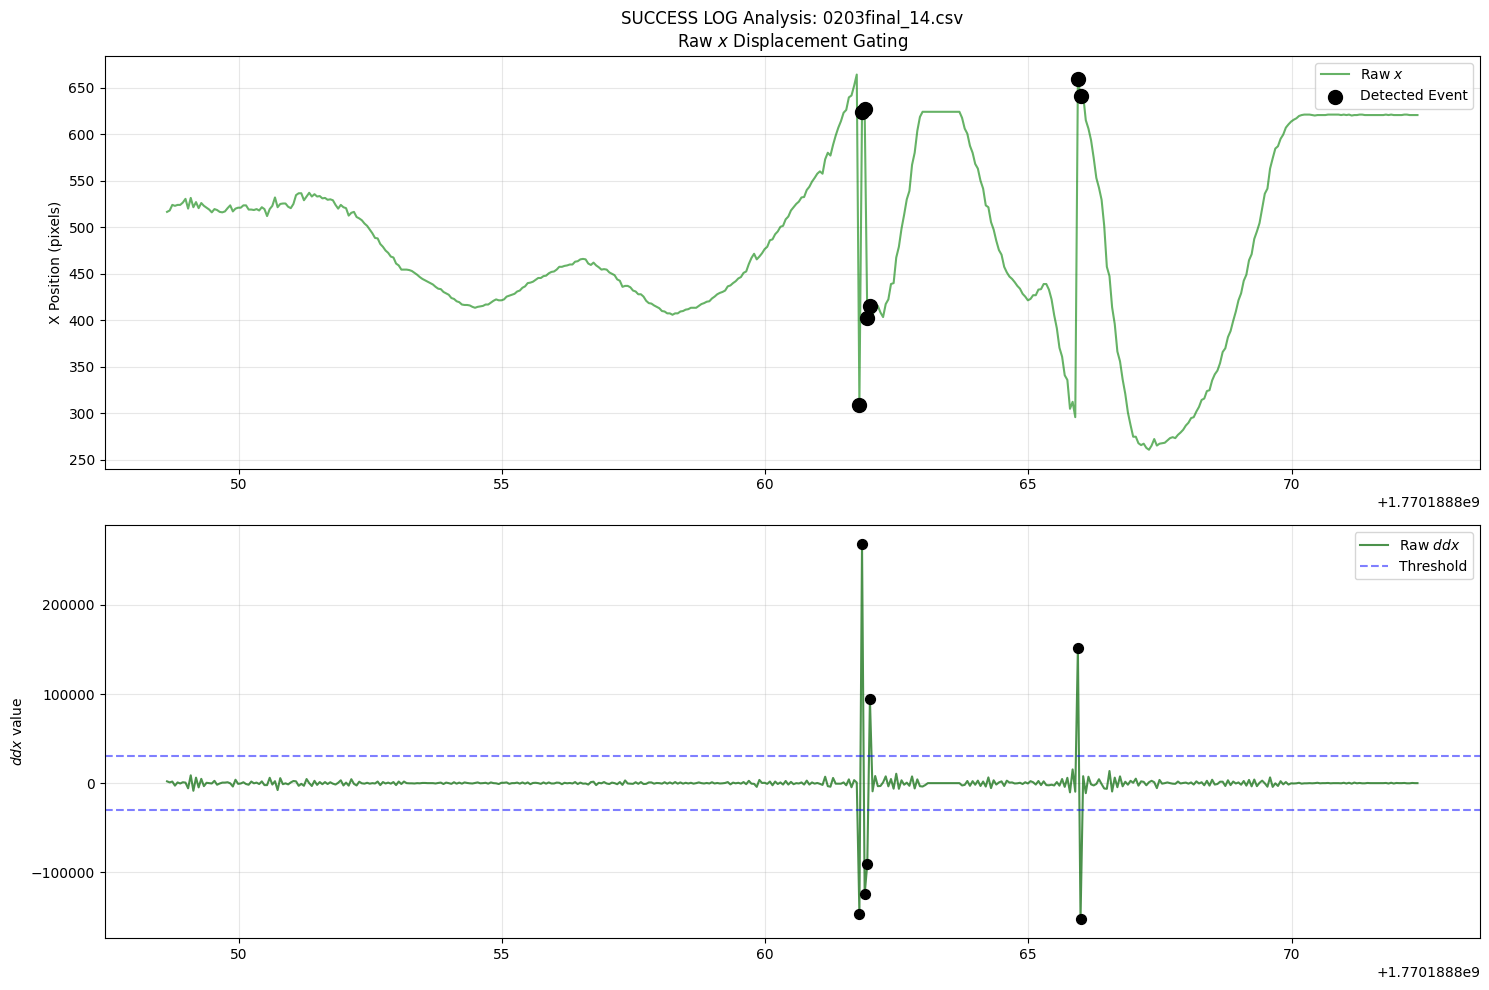

✅ 0203final_14.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [354.5 354.5 354.5 354.5 354.5 363.5 363.5]


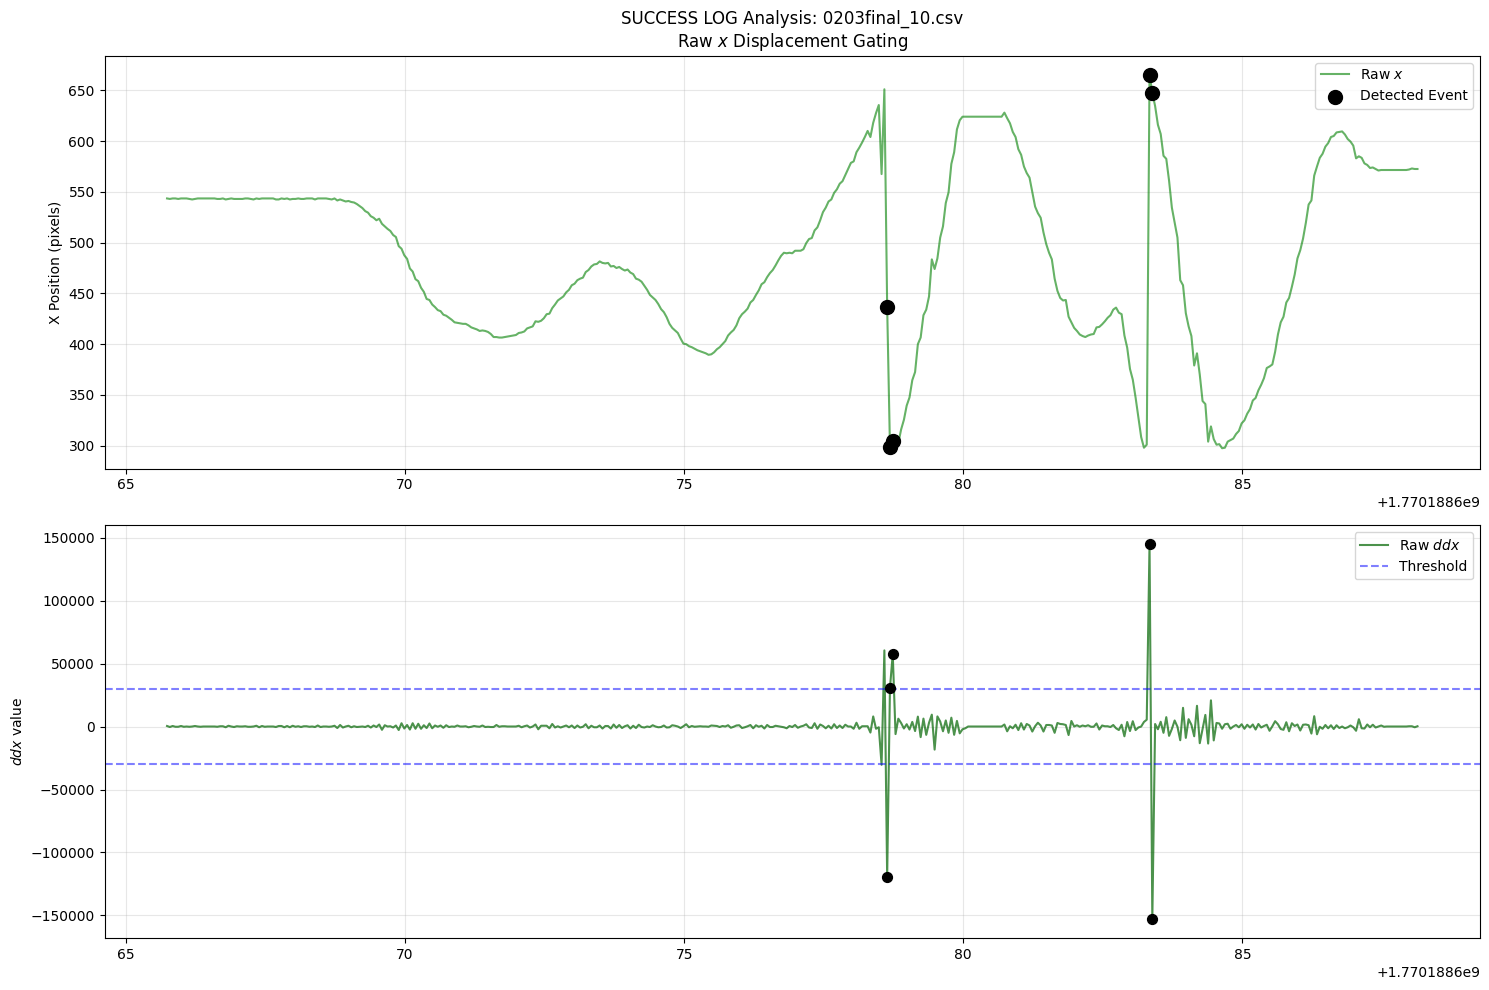

✅ 0203final_10.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [214.  352.  352.  367.5 367.5]


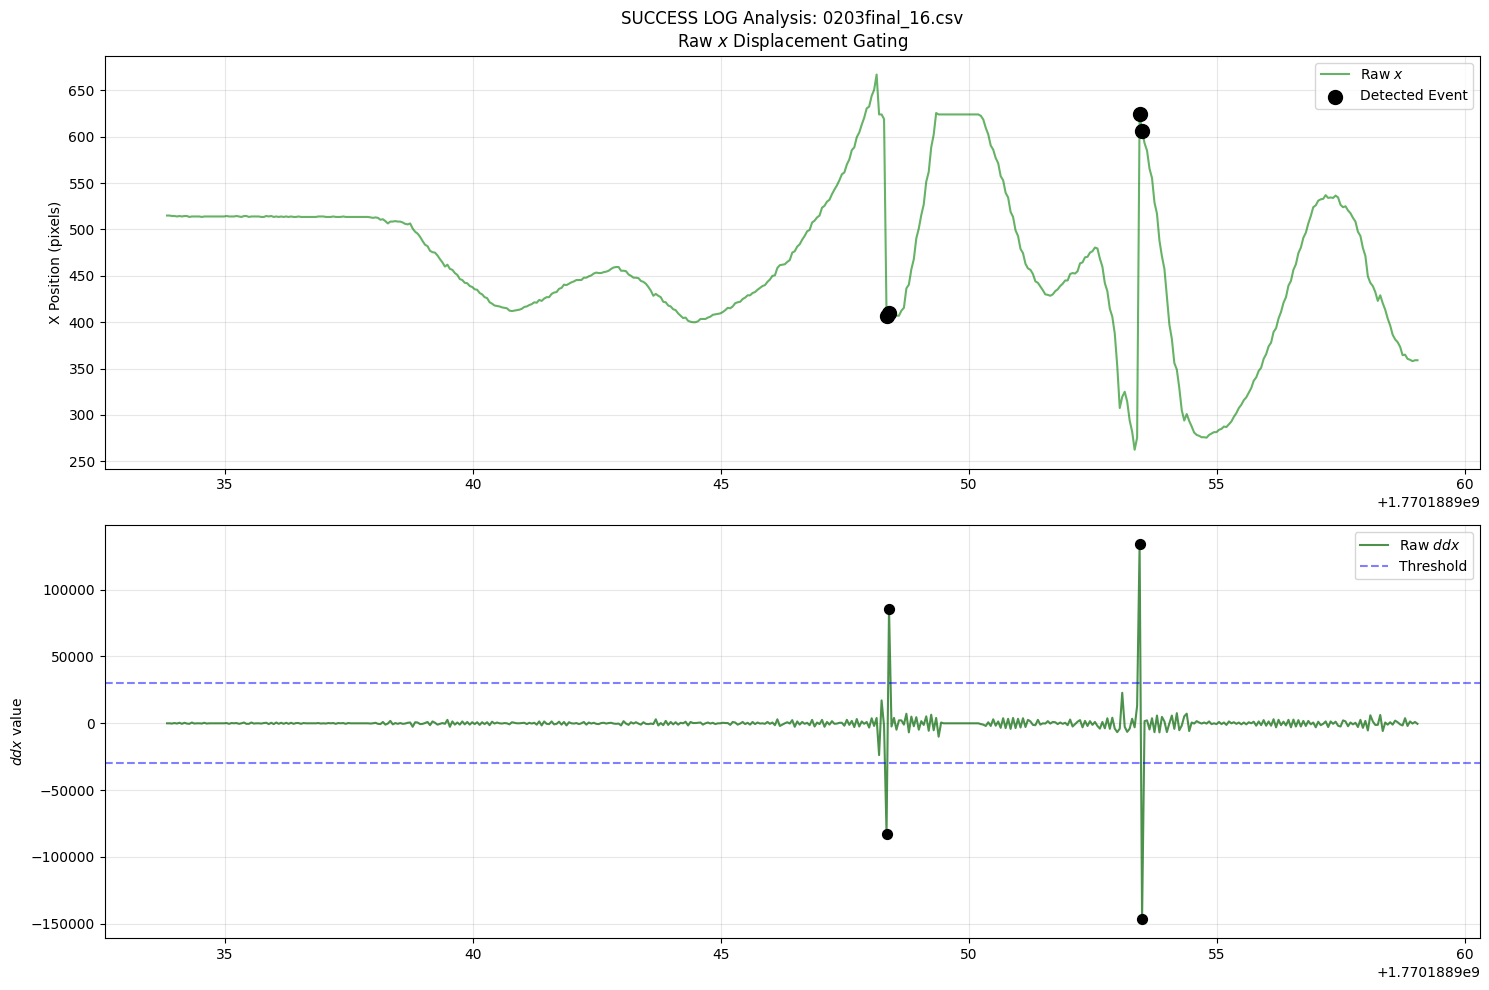

✅ 0203final_16.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [260.  260.  361.5 361.5]


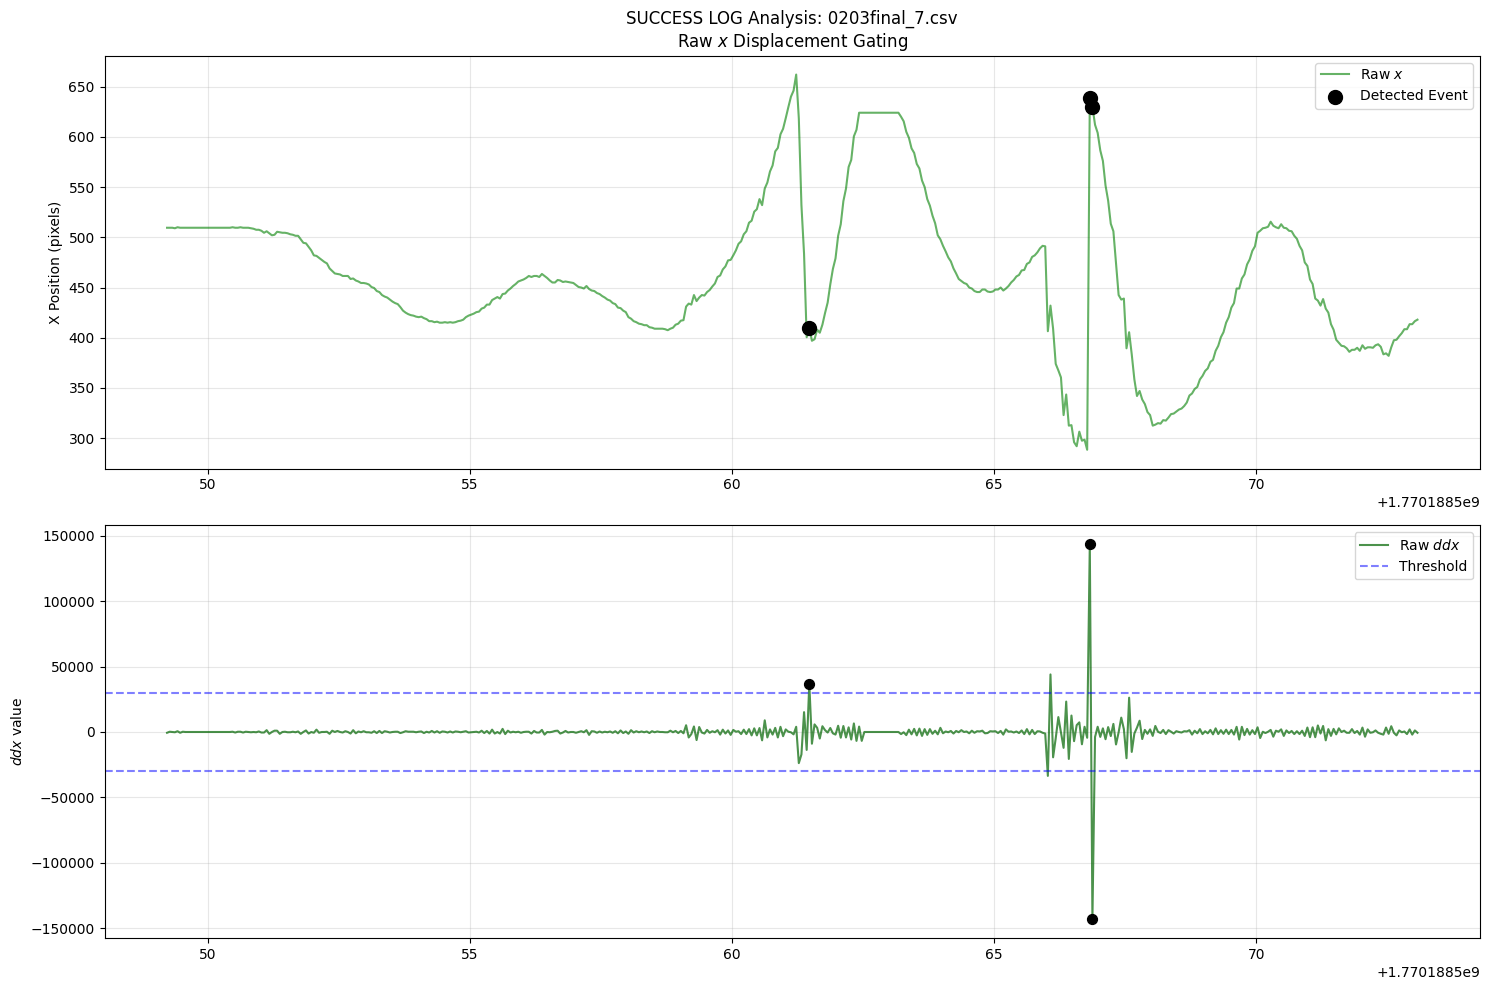

✅ 0203final_7.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [261.5 350.  350. ]


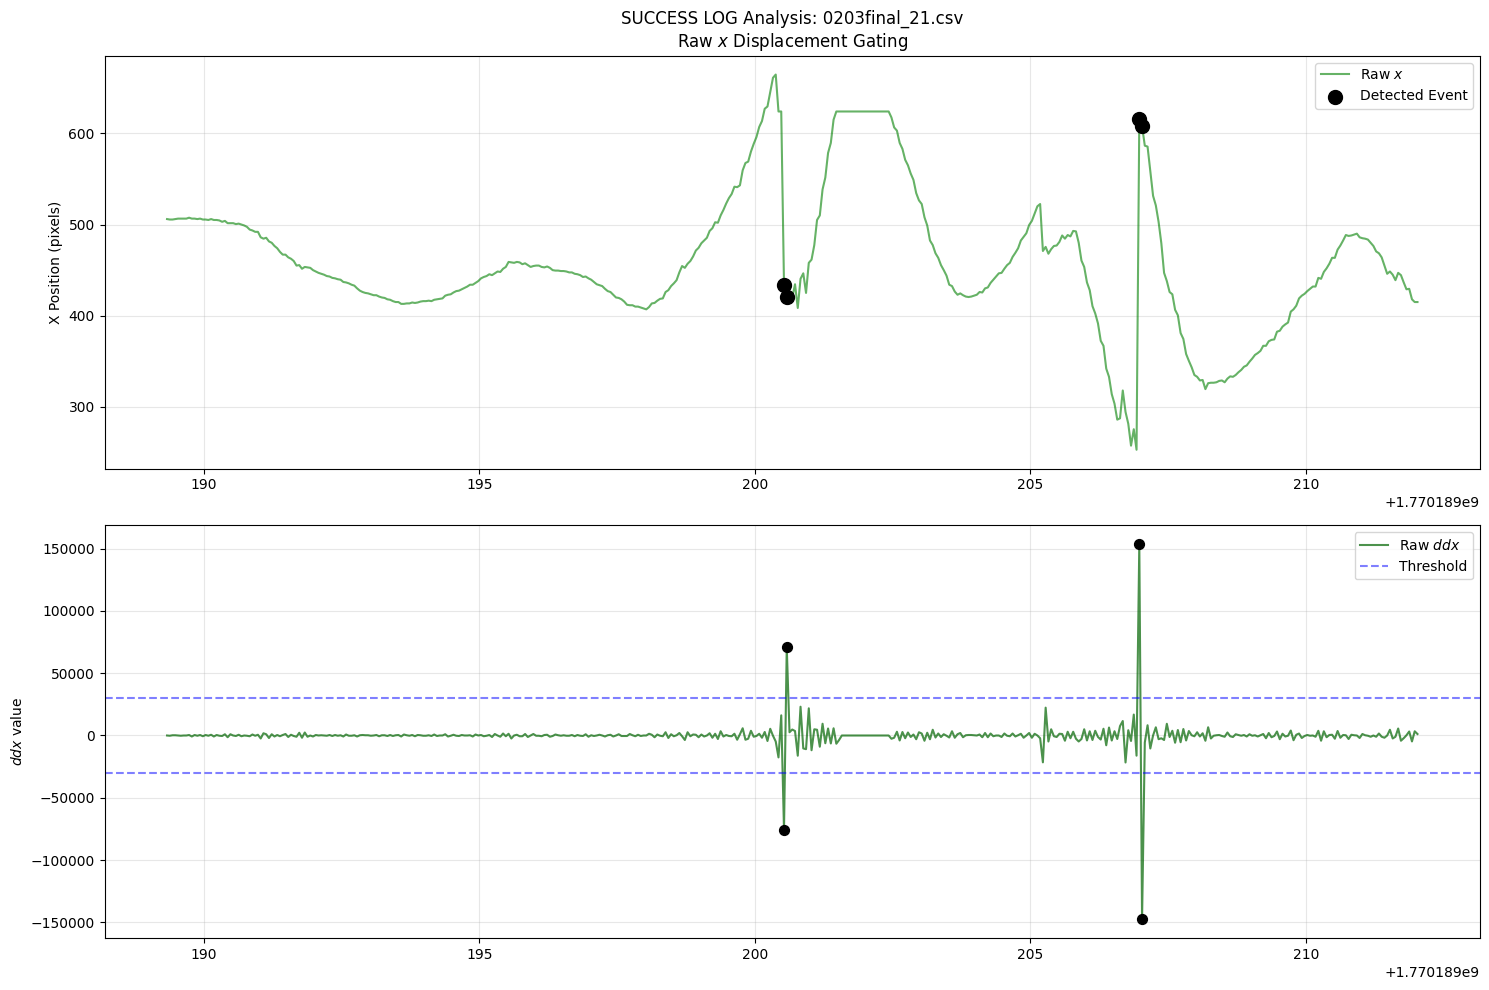

✅ 0203final_21.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [230.5 243.5 362.5 362.5]


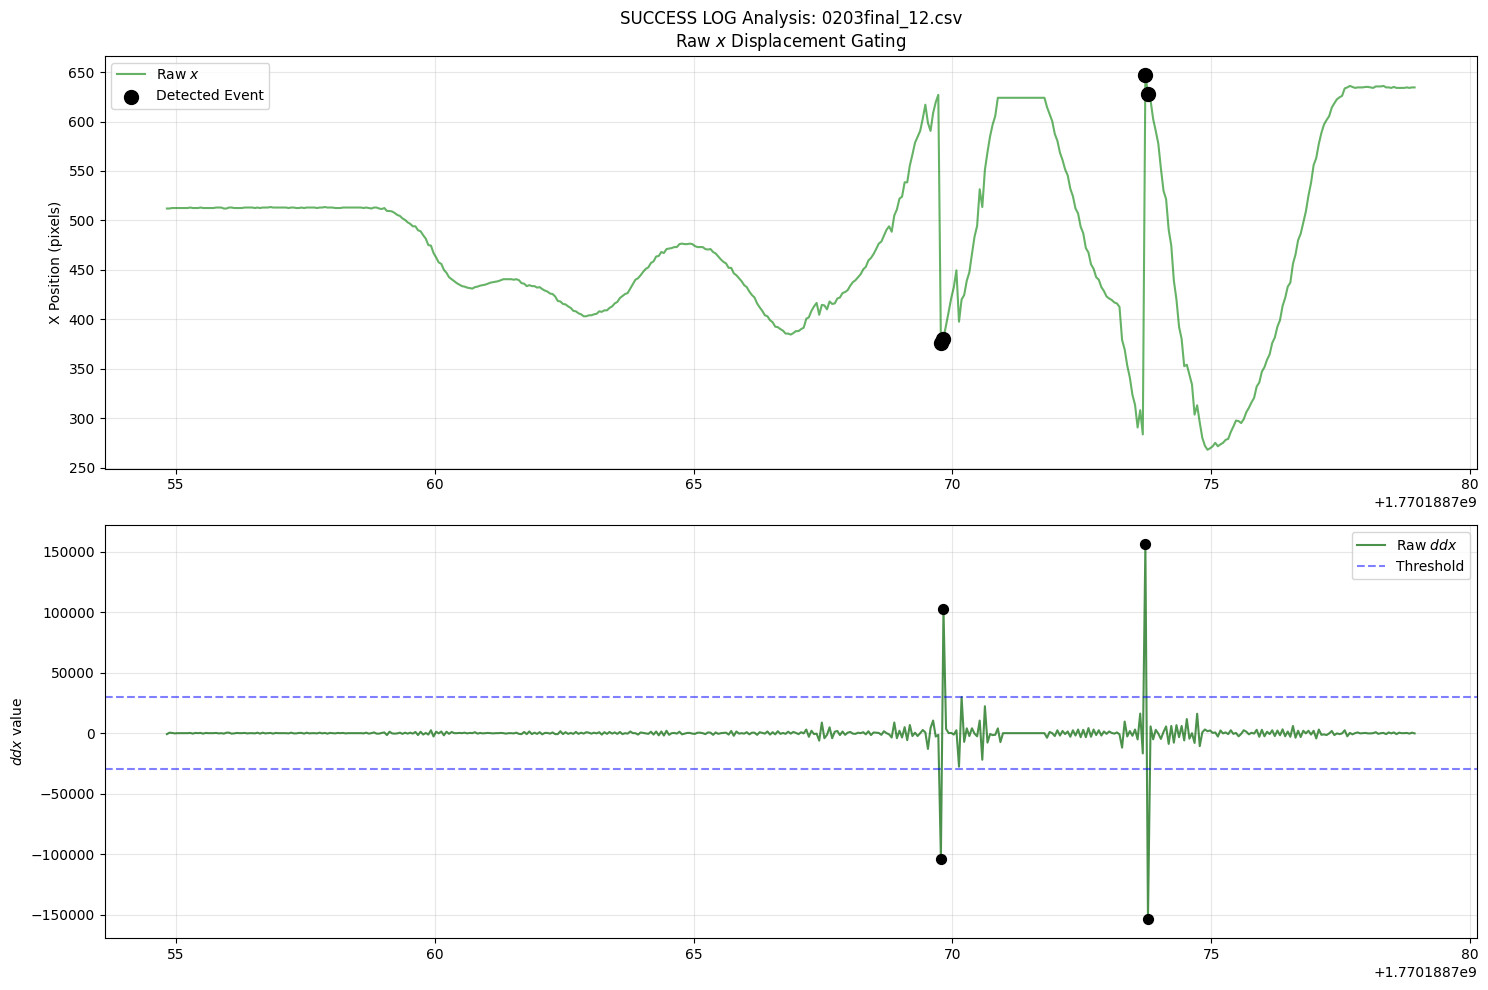

✅ 0203final_12.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [251. 251. 364. 364.]


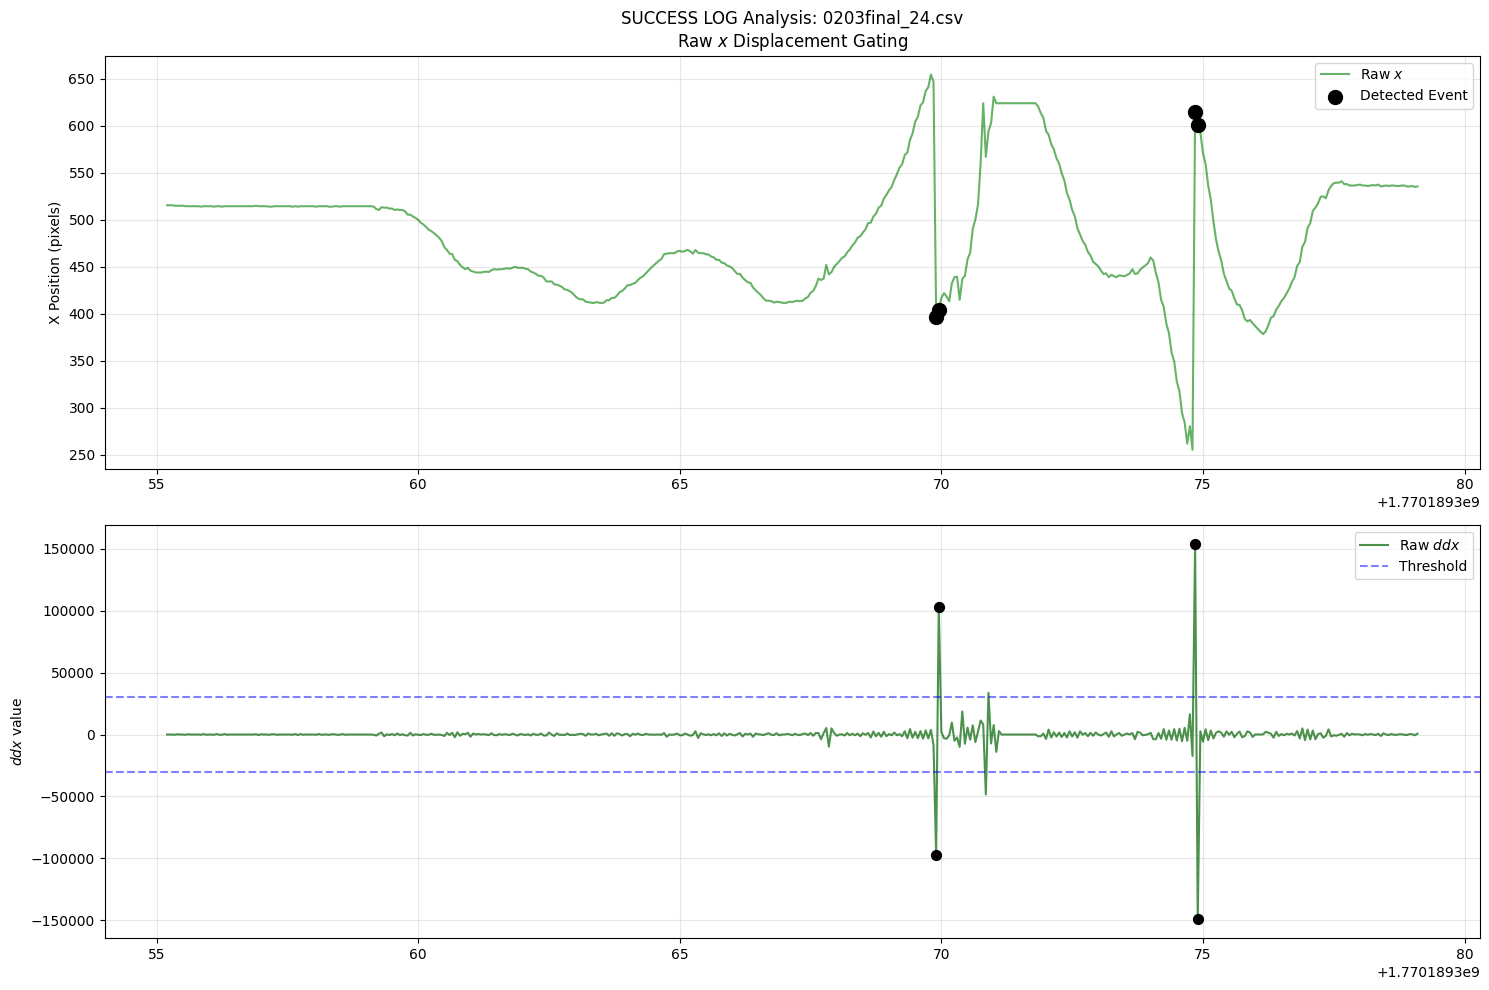

✅ 0203final_24.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [257.5 257.5 359.  359. ]


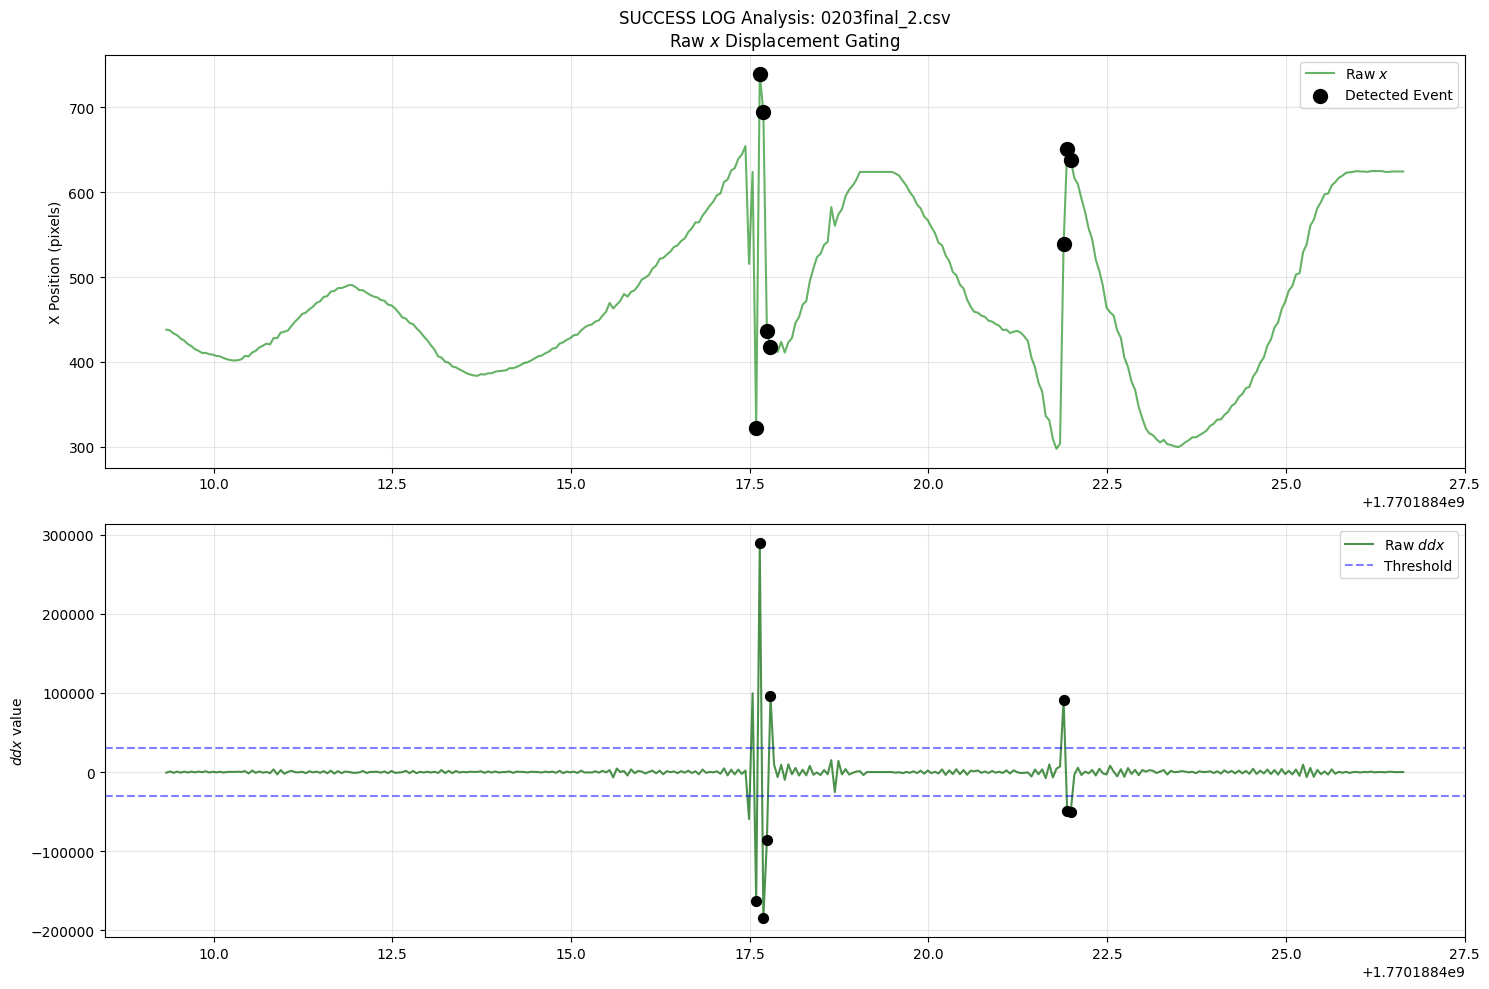

✅ 0203final_2.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [332.5 418.  418.  418.  418.  241.  353.  353. ]


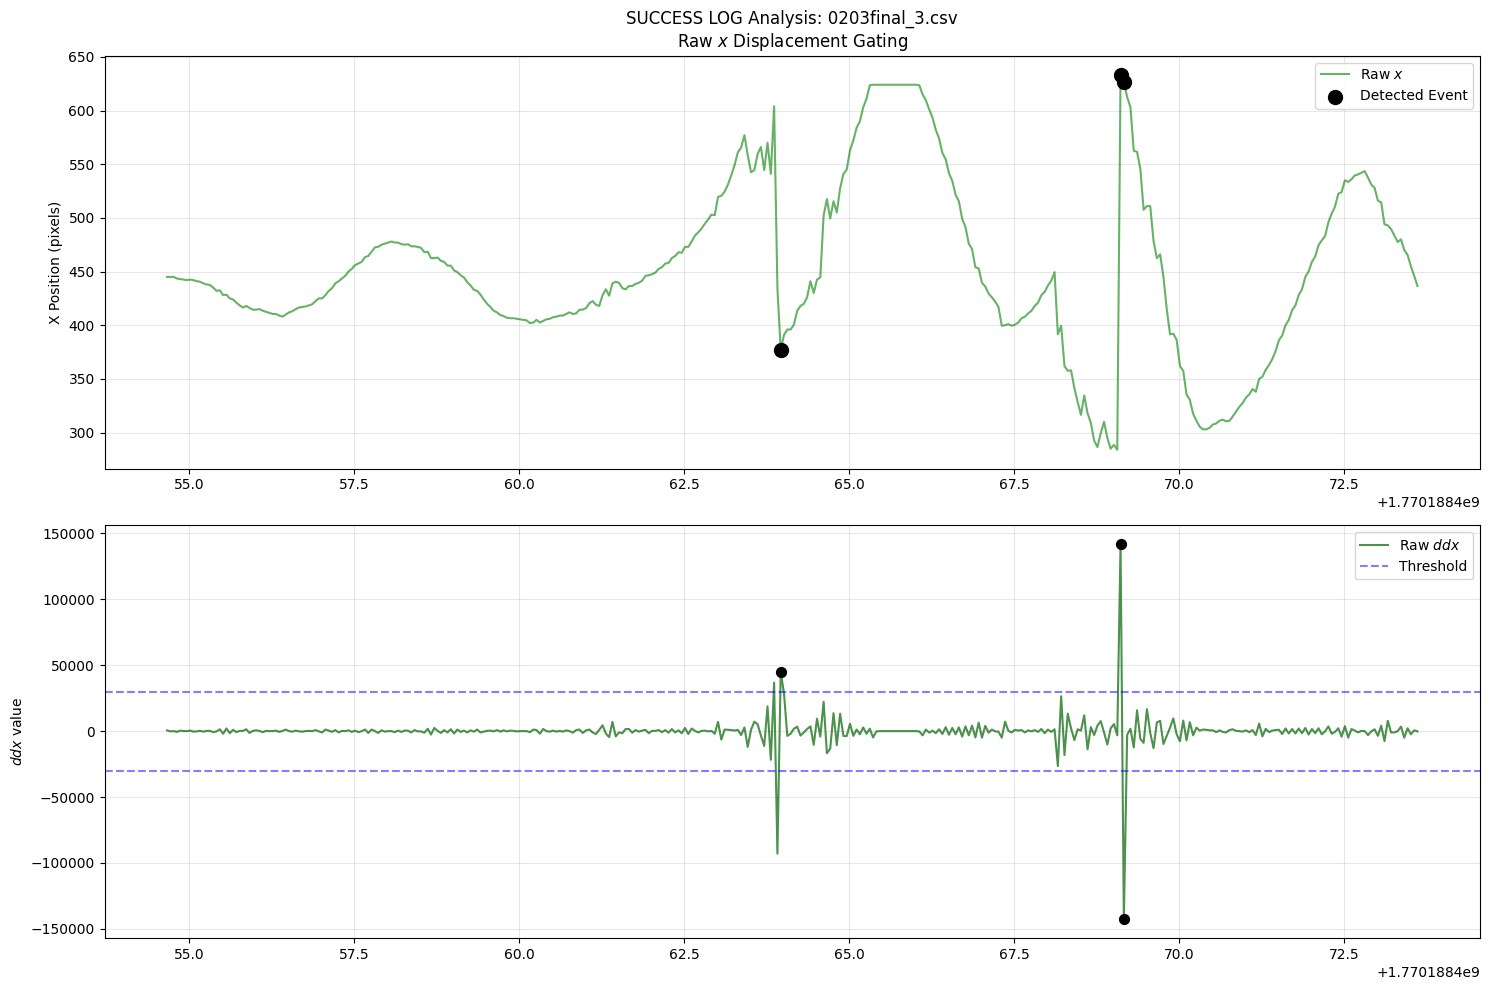

✅ 0203final_3.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [227.  349.5 349.5]


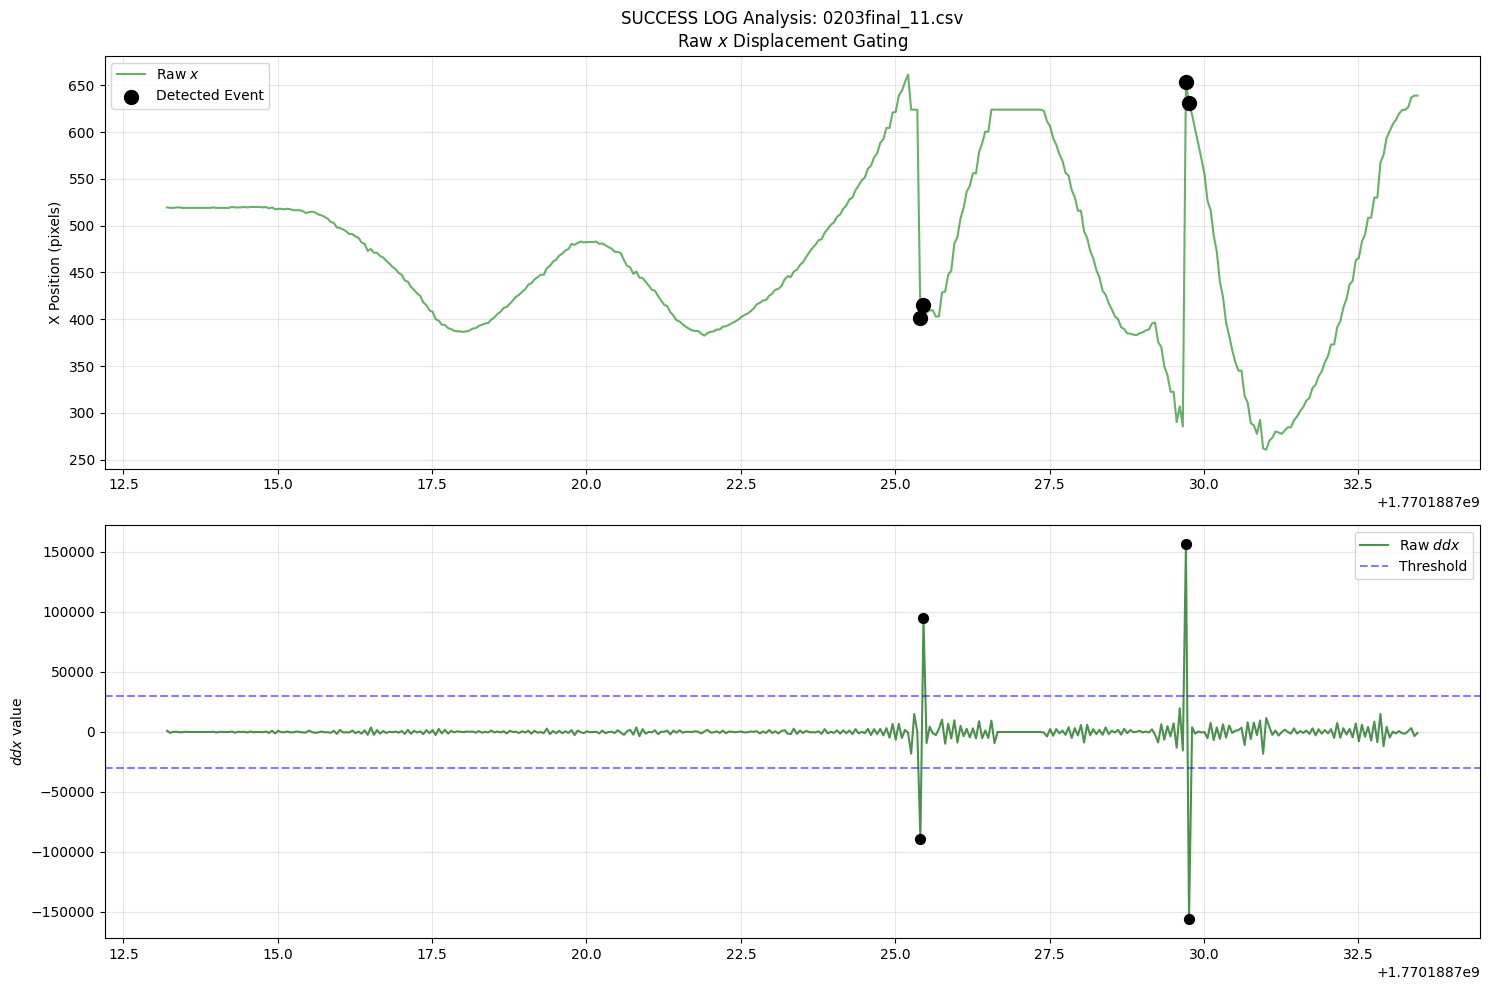

✅ 0203final_11.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [260.5 260.5 368.  368. ]


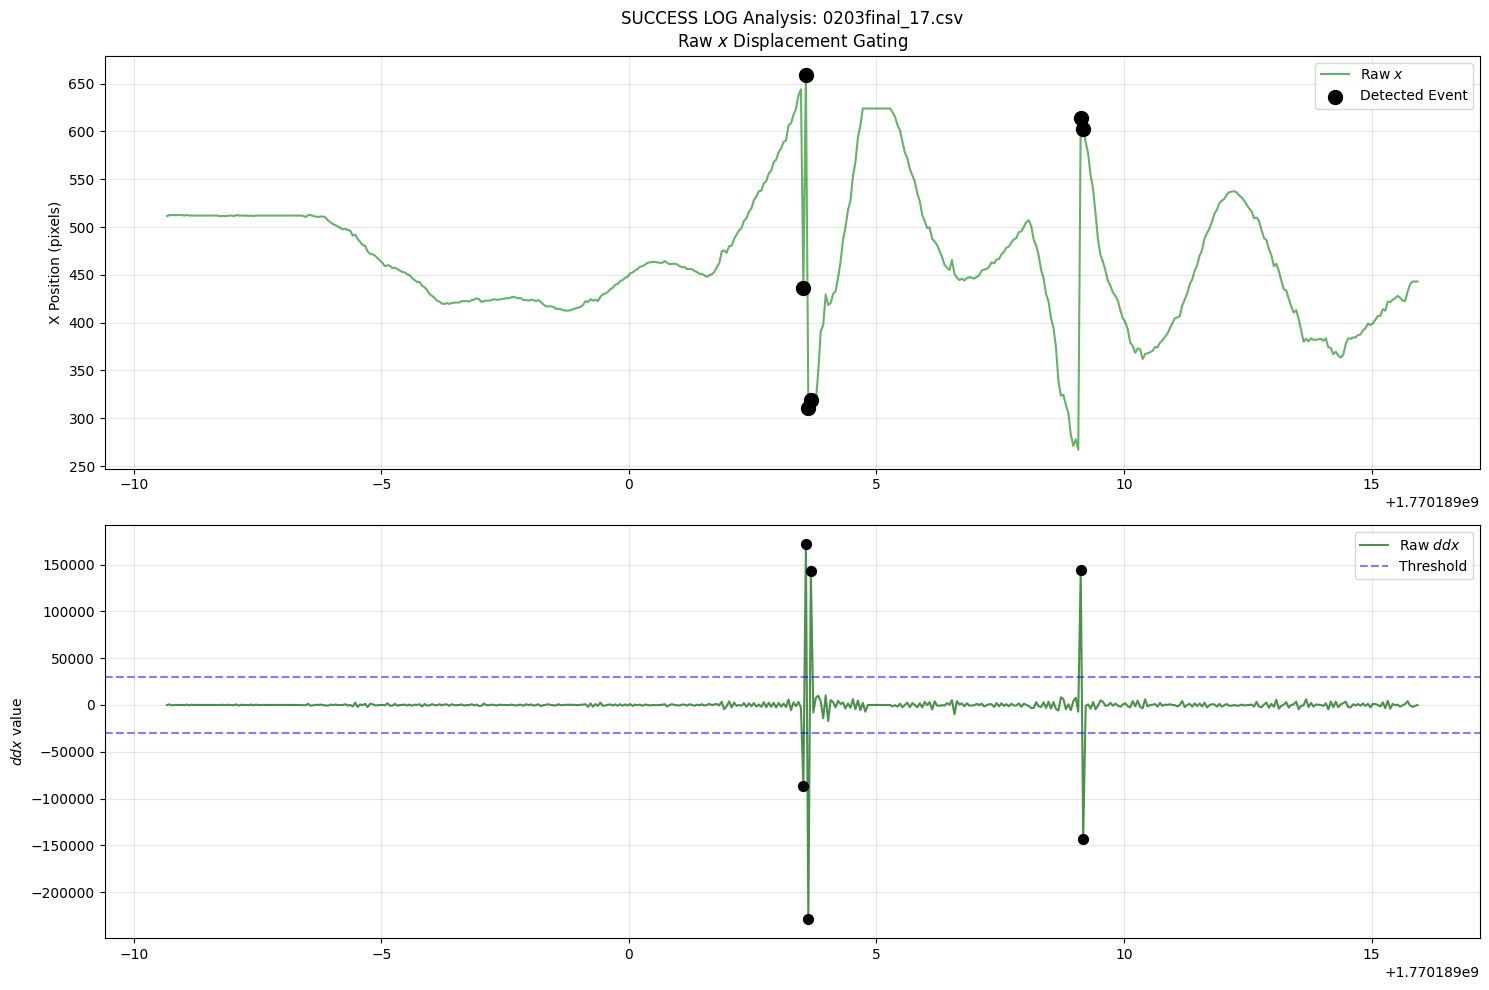

✅ 0203final_17.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [207.5 223.  349.  349.  347.5 347.5]


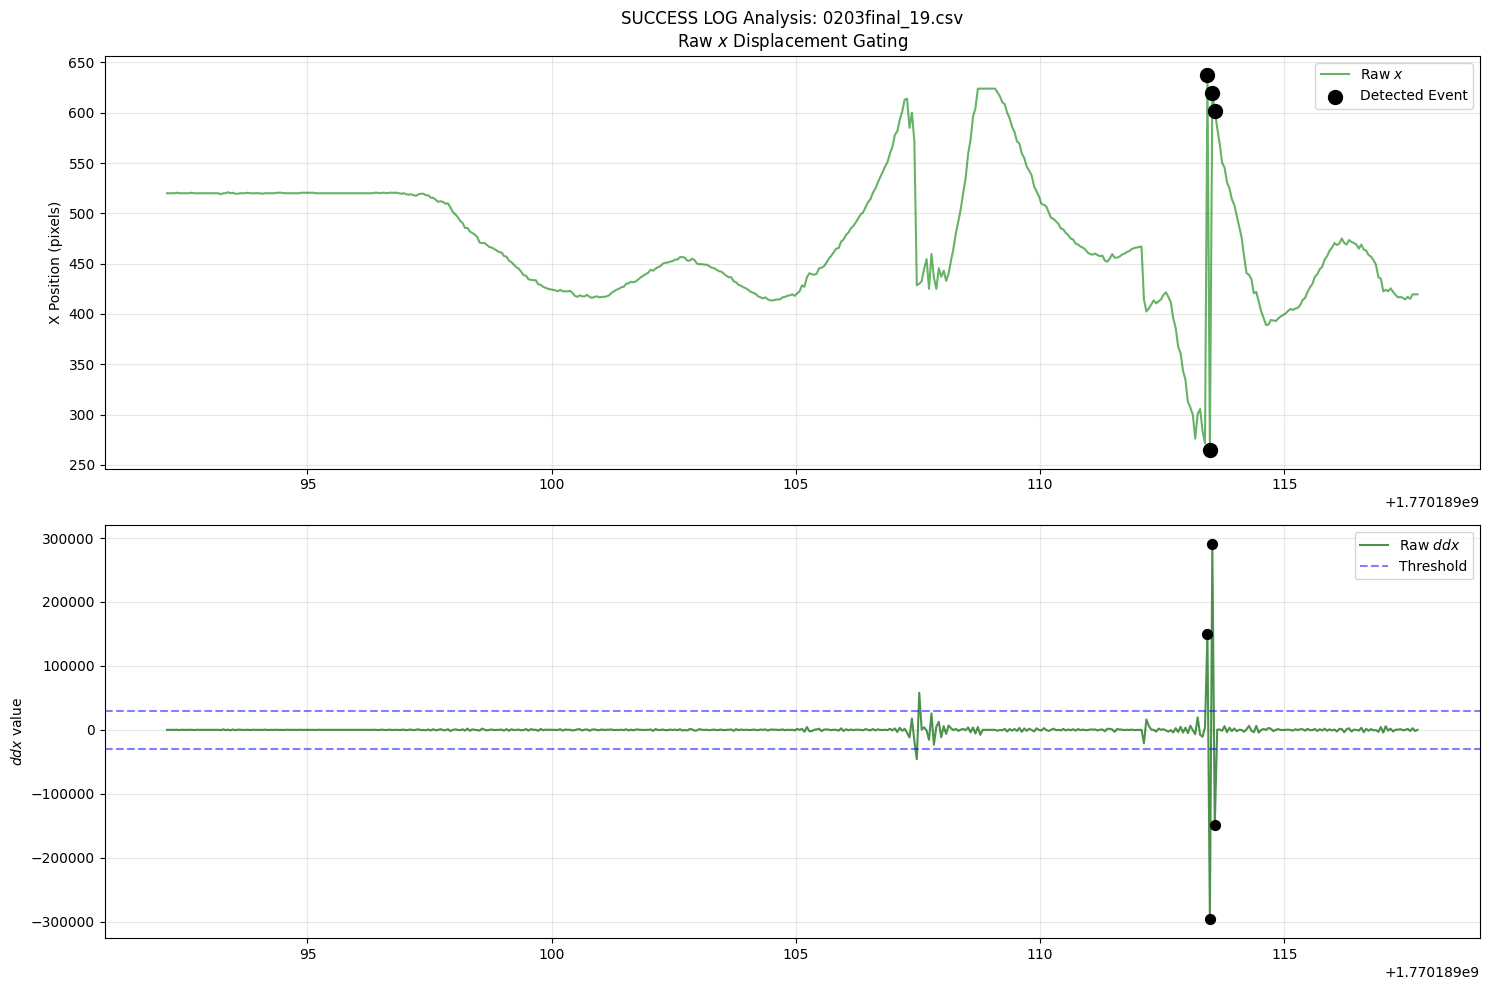

✅ 0203final_19.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [366.5 373.  373.  373. ]


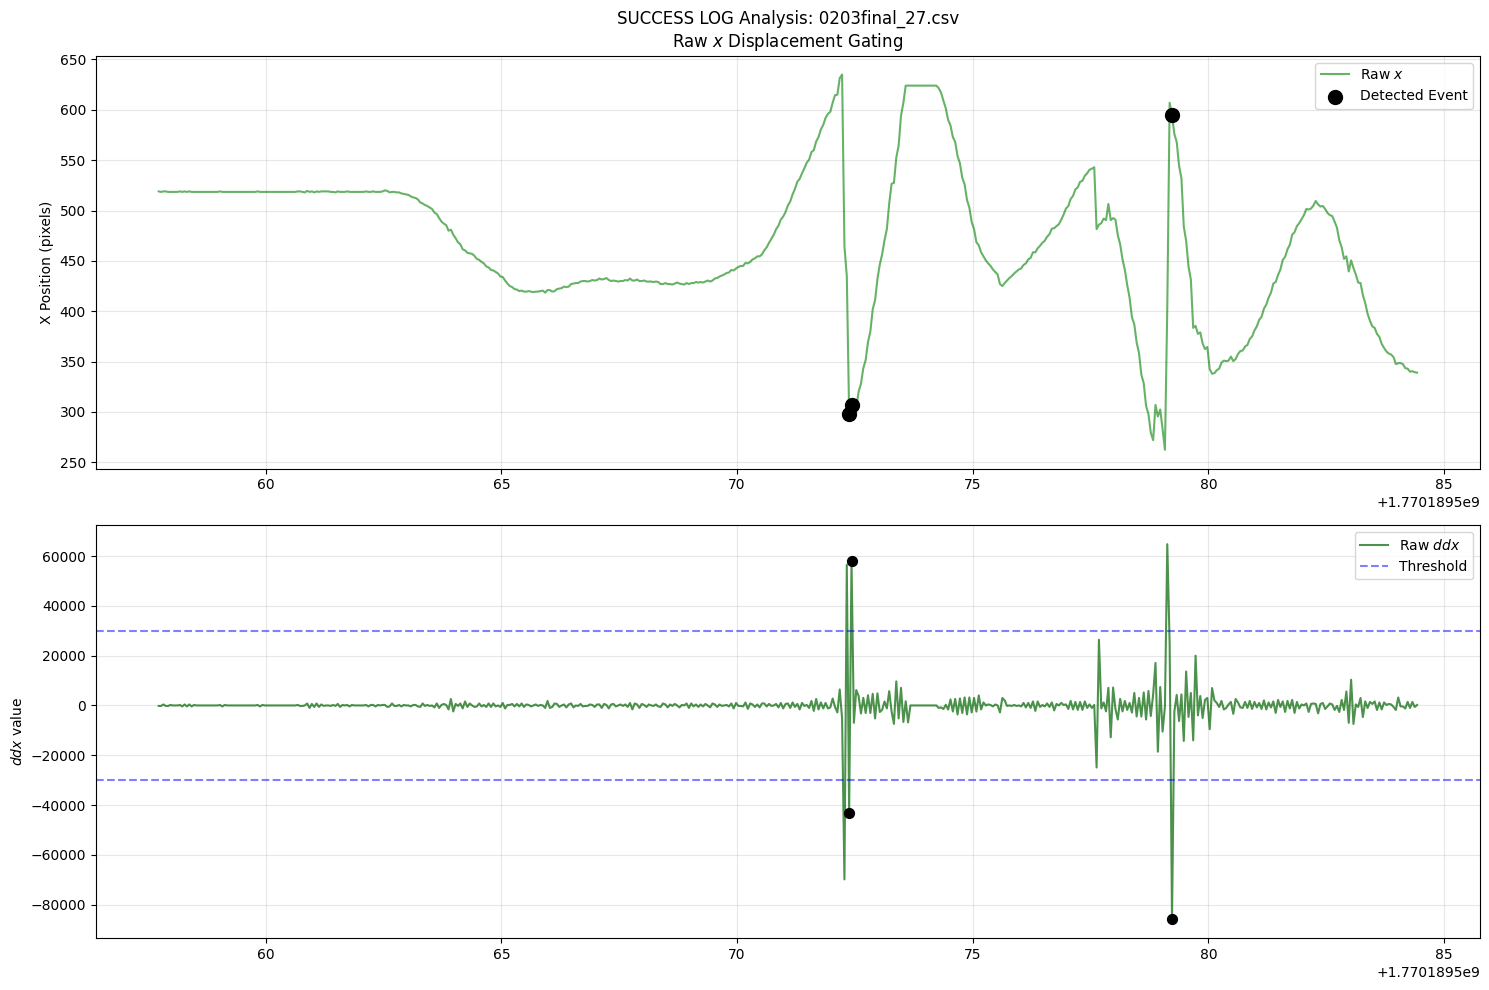

✅ 0203final_27.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [337.  337.  344.5]


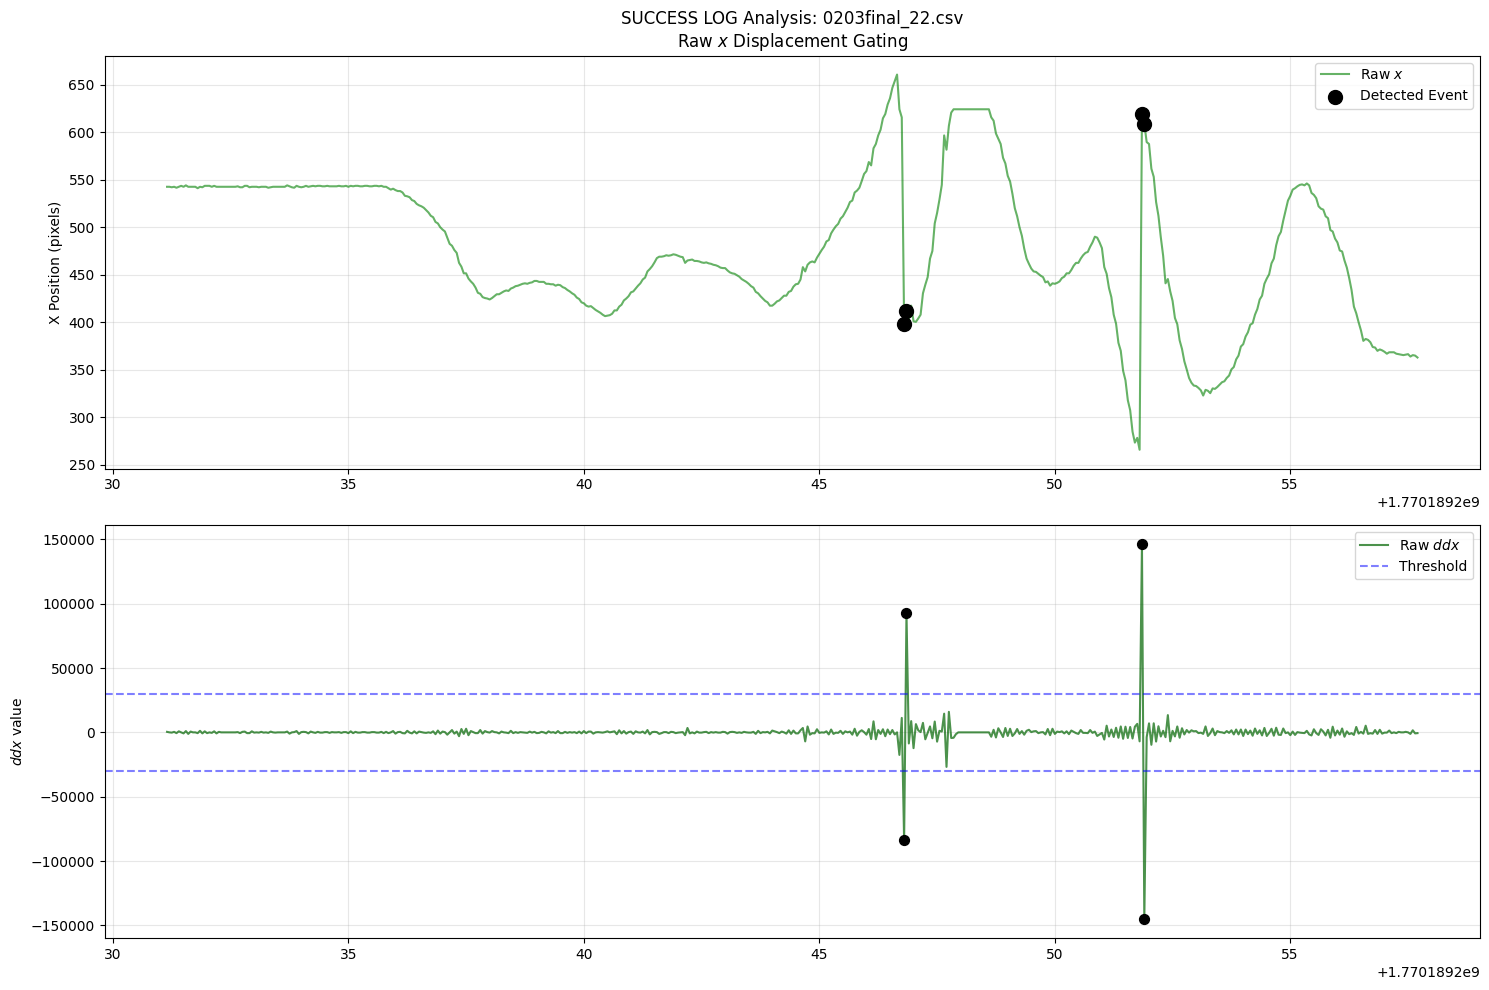

✅ 0203final_22.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [262.5 262.5 353.  353. ]


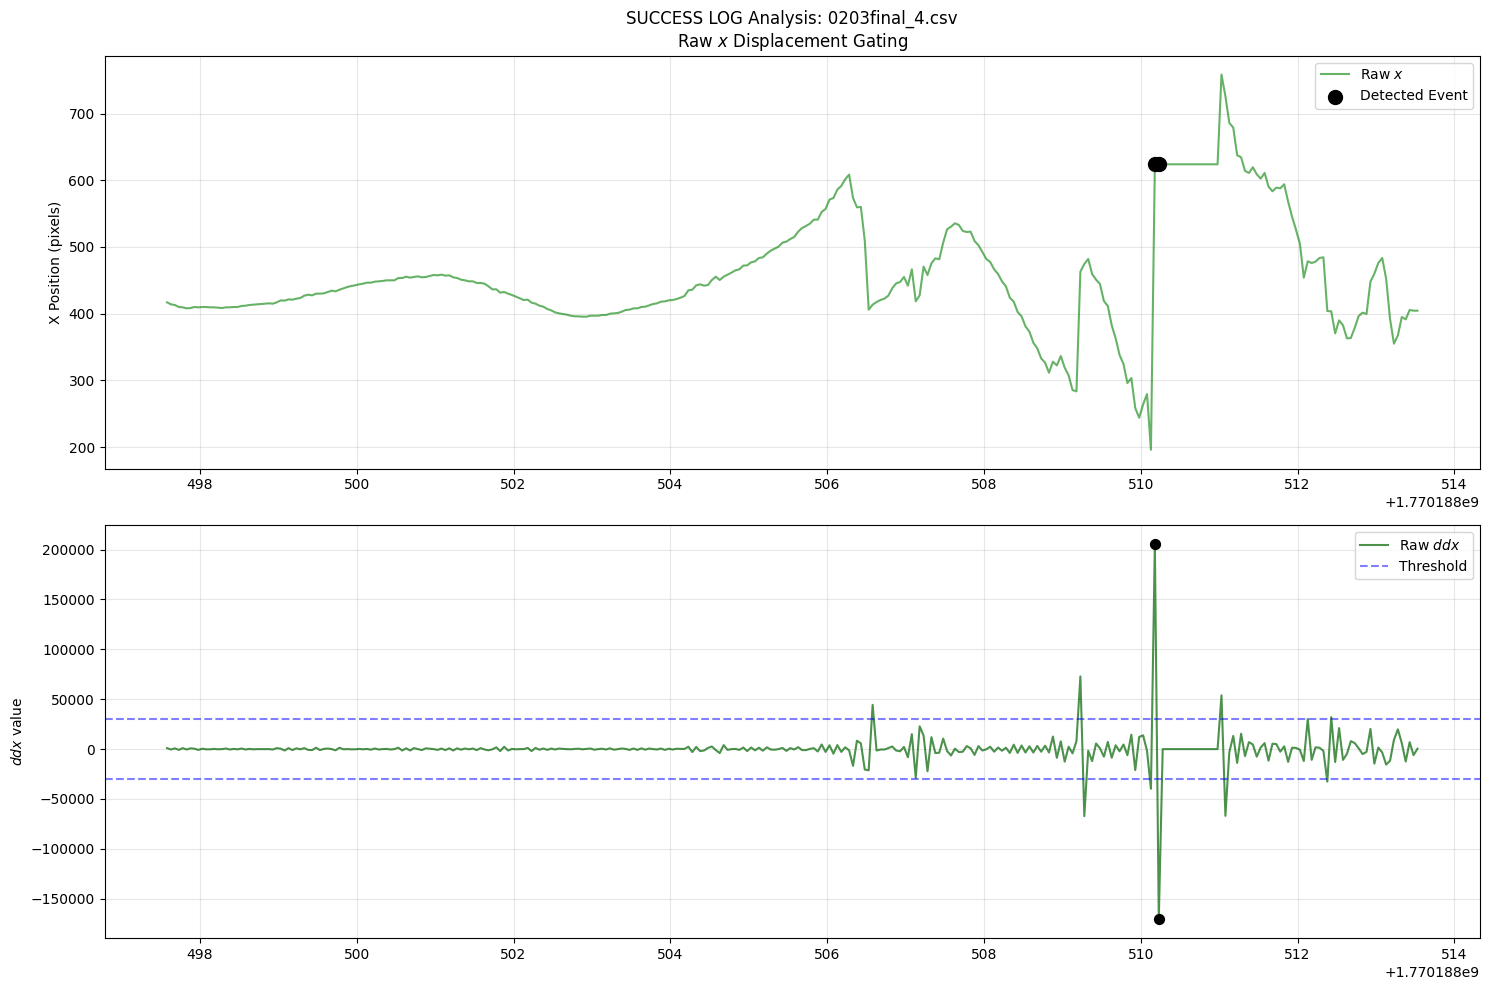

✅ 0203final_4.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [428. 428.]


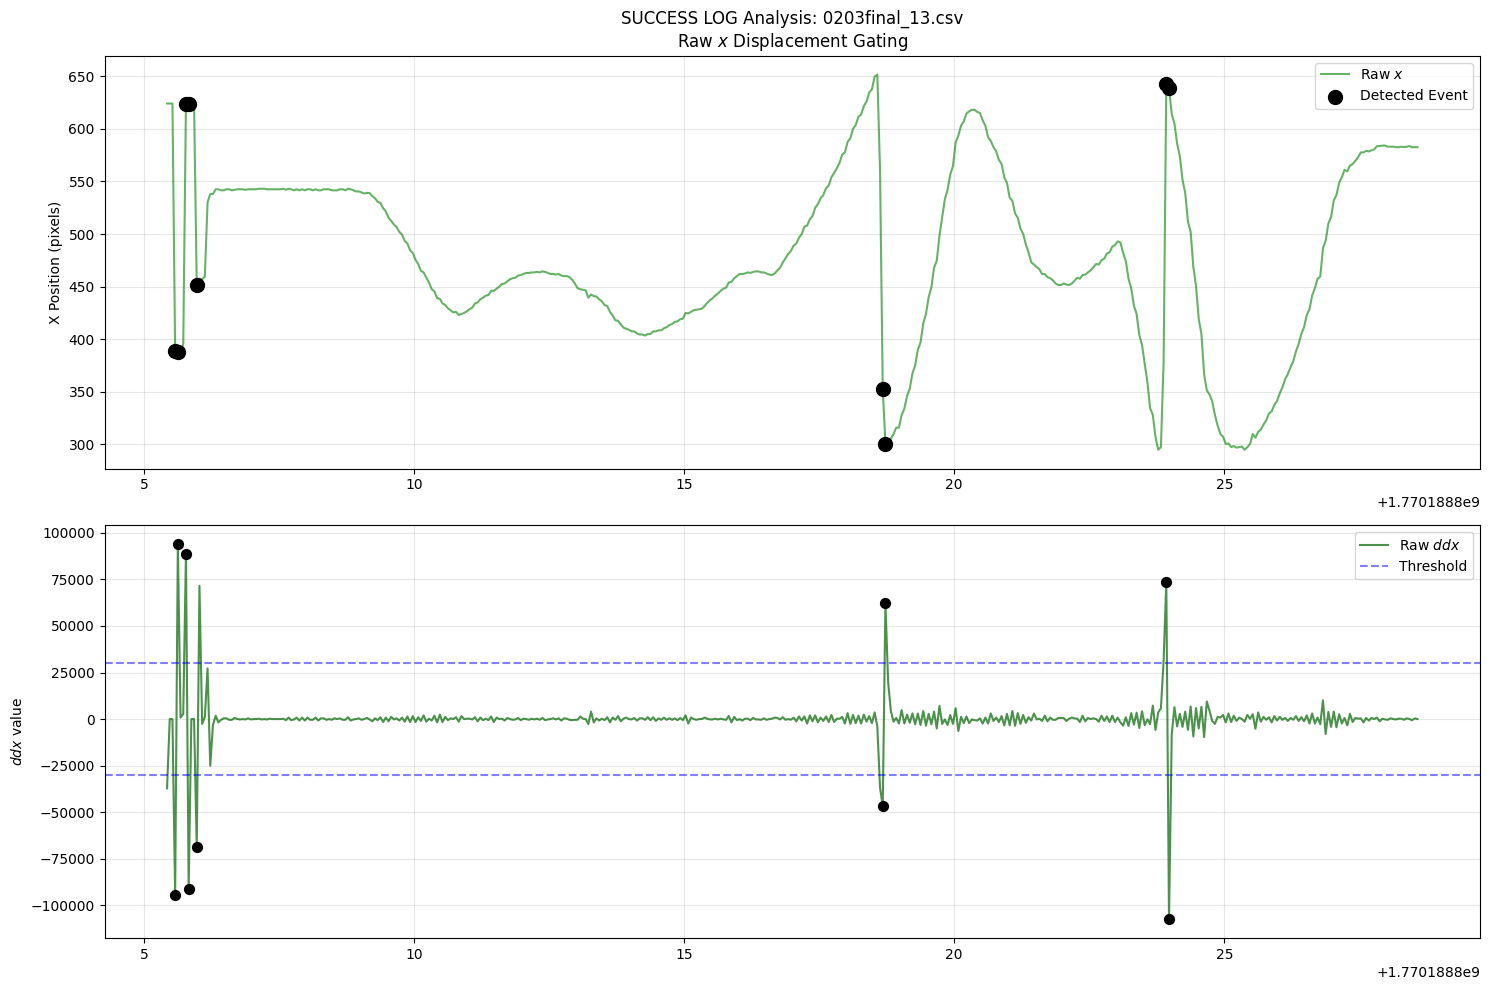

✅ 0203final_13.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [235.  236.5 236.5 236.5 228.5 298.5 351.  348.  348. ]


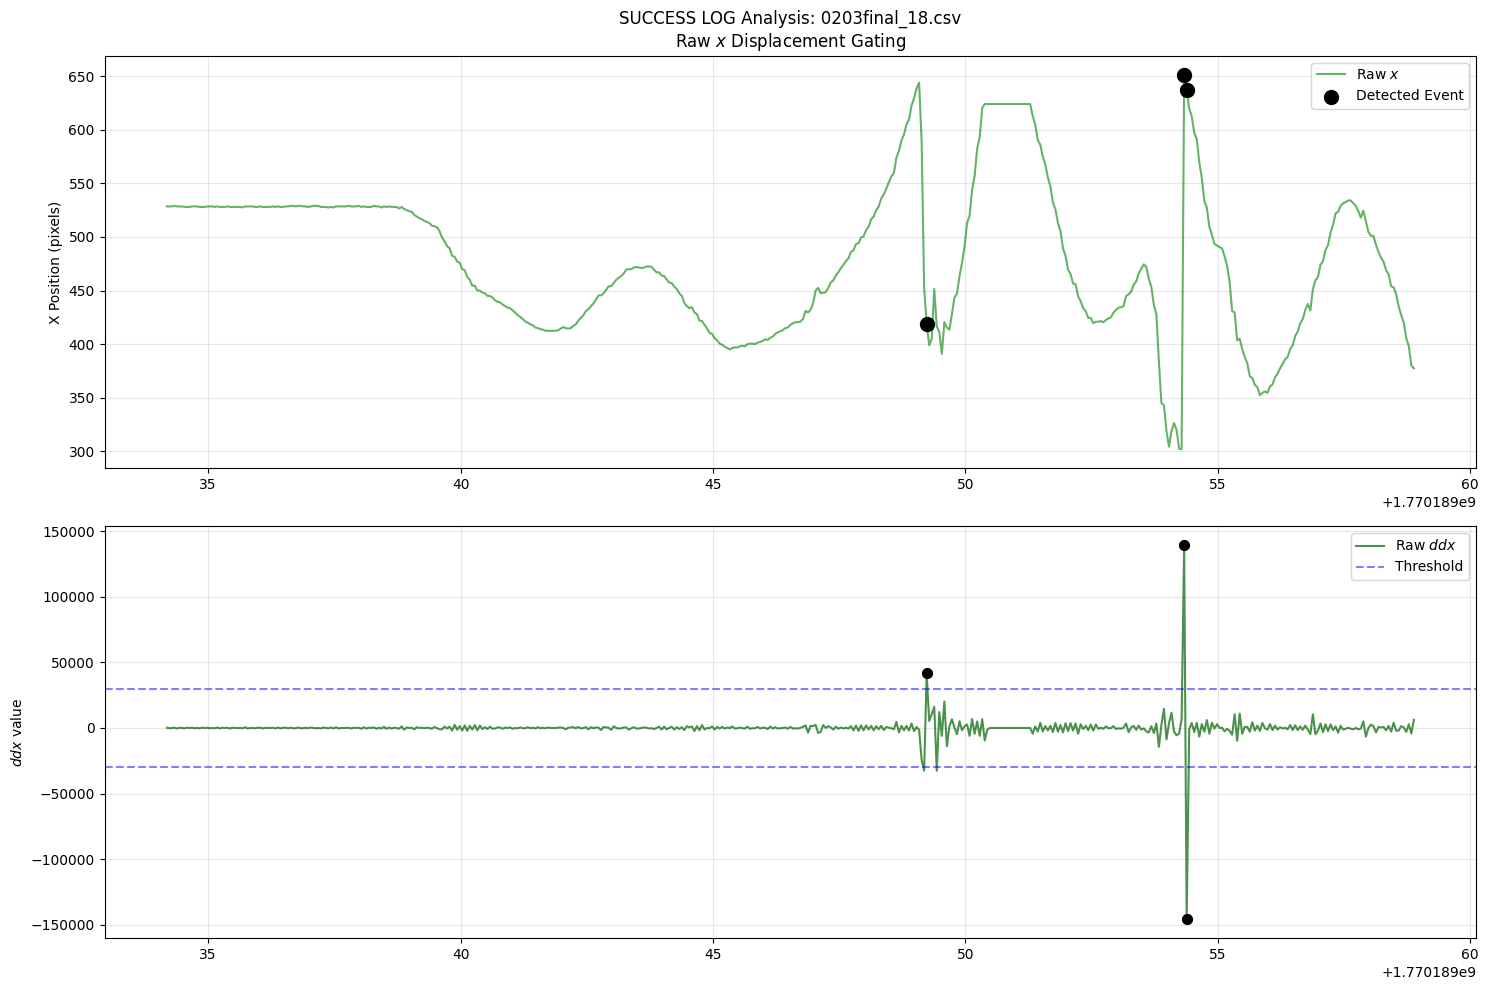

✅ 0203final_18.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [225.  349.5 349.5]


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# 1. 경로 설정 및 파일 리스트 추출
csv_dir = Path.home() / 'lane_change_logs'
csv_files = list(csv_dir.glob('*.csv'))

# 'fail' 또는 '실패'가 이름에 포함되지 않은 파일만 필터링
success_files = [f for f in csv_files if 'fail' not in f.name.lower() and '실패' not in f.name]

if not success_files:
    print('❌ 정상(Success) CSV 파일을 찾을 수 없습니다.')
else:
    print(f'📂 총 {len(success_files)}개의 정상 로그 파일을 분석합니다.')

    for file_path in success_files:
        try:
            # 데이터 로드
            df = pd.read_csv(file_path)
            
            # 컬럼명 공백 제거
            df.columns = df.columns.str.strip()

            # 2. 미분 계산 (Raw x 및 timestamp 사용)
            # dt는 timestamp의 차이이며, 0인 경우 NaN 처리하여 수치 폭주 방지
            dt = df['timestamp'].diff()
            dt = dt.replace(0, np.nan)
            
            df['right_dx'] = df['right_x'].diff() / dt
            df['right_ddx'] = df['right_dx'].diff() / dt
            
            # 3. 설정값 및 이동 거리 계산 (사용자 로직 유지)
            window_size = 6        
            dist_threshold = 200   
            ddx_threshold = 30000  
            
            # 윈도우 내 실제 이동 거리 계산
            df['rolling_dist'] = df['right_x'].rolling(window=window_size).apply(lambda x: x.max() - x.min())
            
            # 결측치 제거
            df_clean = df.dropna(subset=['right_x', 'right_ddx', 'rolling_dist']).copy()
            
            # 4. 최종 게이팅 로직
            # ddx 절대값과 이동 거리가 모두 임계값을 넘어야 함
            df_clean['is_spike'] = (df_clean['right_ddx'].abs() > ddx_threshold) & \
                                   (df_clean['rolling_dist'] > dist_threshold)
            
            spikes = df_clean[df_clean['is_spike']]
            
            # 5. 시각화
            plt.figure(figsize=(15, 10))
            
            # 상단: Raw X Position
            plt.subplot(2, 1, 1)
            plt.plot(df_clean['timestamp'], df_clean['right_x'], color='green', alpha=0.6, label='Raw $x$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['right_x'], color='black', s=100, marker='o', label='Detected Event', zorder=5)
            plt.title(f'SUCCESS LOG Analysis: {file_path.name}\nRaw $x$ Displacement Gating')
            plt.ylabel('X Position (pixels)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # 하단: Raw ddx 그래프
            plt.subplot(2, 1, 2)
            plt.plot(df_clean['timestamp'], df_clean['right_ddx'], color='darkgreen', alpha=0.7, label='Raw $ddx$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['right_ddx'], color='black', s=50, zorder=5)
            plt.axhline(ddx_threshold, color='blue', linestyle='--', alpha=0.5, label='Threshold')
            plt.axhline(-ddx_threshold, color='blue', linestyle='--', alpha=0.5)
            plt.ylabel('$ddx$ value')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

            if not spikes.empty:
                print(f"✅ {file_path.name}: 정상 데이터에서도 이벤트가 검출되었습니다.")
                print(f"   검출 시점 이동 거리: {spikes['rolling_dist'].values}")
            else:
                print(f"ℹ️ {file_path.name}: 특이 사항 없음 (스파이크 미검출)")

        except Exception as e:
            print(f"❌ {file_path.name} 처리 중 에러 발생: {e}")